In [2]:
import os

path = "/kaggle/input/rice-image-dataset/Rice_Image_Dataset"
print(os.listdir(path))

['Karacadag', 'Basmati', 'Jasmine', 'Rice_Citation_Request.txt', 'Arborio', 'Ipsala']


# Derin Öğrenme ile Pirinç Çeşitlerinin Otomatik Sınıflandırılması: CNN ve VGG16

Bu proje, Rice Image Dataset kullanılarak beş farklı pirinç çeşidinin (Arborio, Basmati, Ipsala, Jasmine, Karacadag) görüntü işleme ve derin öğrenme teknikleriyle yüksek doğrulukla ayırt edilmesini amaçlar. Çalışma kapsamında, sıfırdan tasarlanan Özgün CNN Mimarisi ile önceden eğitilmiş VGG16 Transfer Öğrenme modeli geliştirilmiş ve performansları karşılaştırılmıştır. Eğitilen modellerin başarımı test edilerek, sonuçlardan bahsedilmektedir.

In [1]:
# !pip install protobuf==3.20.3

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization, Input, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# GPU Kontrolü
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

2025-12-04 16:33:23.442951: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764866003.669973      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764866003.735424      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
# statik veriler tanimliyoruz
DATA_DIR = "/kaggle/input/rice-image-dataset/Rice_Image_Dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
RANDOM_SEED = 42

In [3]:
# Sınıfları listele (Rice_Citation_Request.txt hariç)
classes = [c for c in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, c))]
print("Sınıflar:", classes)

Sınıflar: ['Karacadag', 'Basmati', 'Jasmine', 'Arborio', 'Ipsala']


In [11]:
# Veri Dağılımını Görselleştirme
class_counts = {}
for c in classes:
    class_counts[c] = len(os.listdir(os.path.join(DATA_DIR, c)))

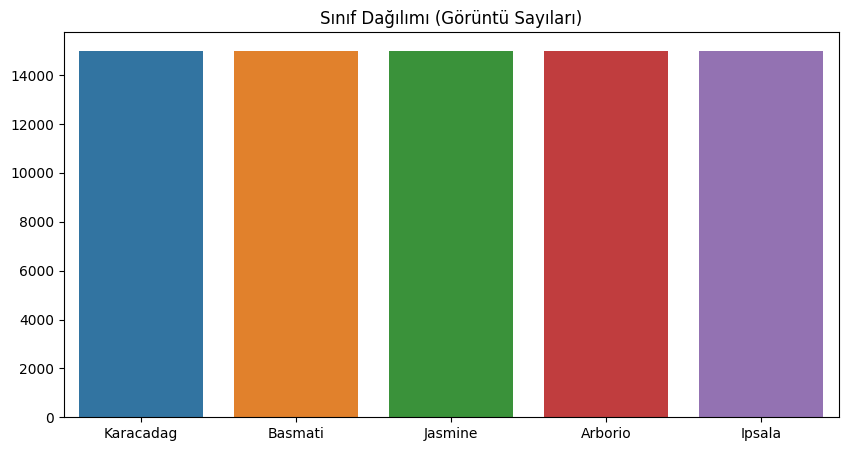

In [12]:
plt.figure(figsize=(10, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title("Sınıf Dağılımı (Görüntü Sayıları)")
plt.show()

In [13]:
# Veri Artırma ve Yükleme
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,  # %20 Doğrulama (Validation)
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [14]:
# Eğitim Seti
train_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=RANDOM_SEED,
    classes=classes
)

Found 60000 images belonging to 5 classes.


In [15]:
# Doğrulama Seti (Test için de kullanılabilir)
val_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=RANDOM_SEED,
    classes=classes
)

Found 15000 images belonging to 5 classes.


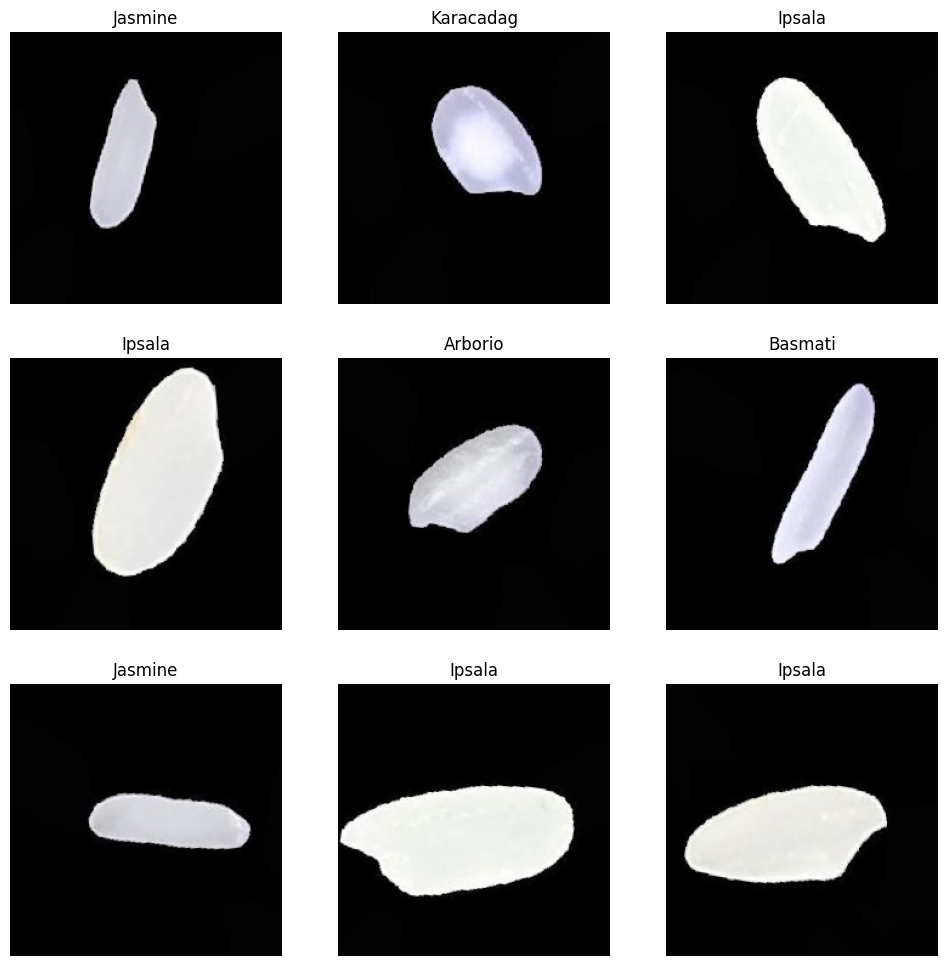

In [18]:
# Örnek resimleri gösterelim
x_batch, y_batch = next(train_gen)
plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_batch[i])
    label_index = np.argmax(y_batch[i])
    plt.title(classes[label_index]) 
    plt.axis("off")
plt.show()

### Custom Deep CNN

In [19]:
# En az 5 Konvolüsyon katmanı, en az 3 Havuzlama katmanı, düzenlileştirme (Dropout/BatchNormalization).
def build_custom_cnn(input_shape, num_classes):
    model = Sequential([
        # Katman 1
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        # Katman 2
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        # Katman 3
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        # Katman 4 (Ekstra Derinlik)
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        # Katman 5 (Ekstra Derinlik)
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        # Düzleştirme ve Tam Bağlantılı Katmanlar
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax') # 5 Sınıf için Softmax
    ])
    return model

In [20]:
# Modeli Oluştur
custom_model = build_custom_cnn((224, 224, 3), 5)

I0000 00:00:1764789838.133037      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764789838.133798      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [21]:
# Modeli Derle
custom_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', 'Precision', 'Recall'])

In [22]:
custom_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 14,616,485 (55.76 MB)

 Trainable params: 14,613,477 (55.75 MB)

 Non-trainable params: 3,008 (11.75 KB)

In [23]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

In [24]:
# Modeli Eğit
history_custom = custom_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/20


I0000 00:00:1764789982.770990     186 service.cc:148] XLA service 0x7fecc001df50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764789982.771576     186 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764789982.771594     186 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764789983.605260     186 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1764790002.284486     186 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1361s 713ms/step - Precision: 0.8973 - Recall: 0.8696 - accuracy: 0.8830 - loss: 0.3300 - val_Precision: 0.2098 - val_Recall: 0.2098 - val_accuracy: 0.2099 - val_loss: 7.7671 - learning_rate: 0.0010
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 942s 502ms/step - Precision: 0.9740 - Recall: 0.9720 - accuracy: 0.9731 - loss: 0.0785 - val_Precision: 0.9817 - val_Recall: 0.9811 - val_accuracy: 0.9815 - val_loss: 0.1063 - learning_rate: 0.0010
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 905s 483ms/step - Precision: 0.9820 - Recall: 0.9810 - accuracy: 0.9816 - loss: 0.0537 - val_Precision: 0.8851 - val_Recall: 0.8836 - val_accuracy: 0.8844 - val_loss: 0.5512 - learning_rate: 0.0010
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 876s 467ms/step - Precision: 0.9818 - Recall: 0.9809 - accuracy: 0.9814 - loss: 0.0577 - val_Precision: 0.9347 - val_Recall: 0.9288 - val_accuracy: 0.9316 - val_loss: 0.2571 - learning_rate: 0.0010
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 860s 459

#### 0.9946 accuracy ve 0.9959 val_accuracy elde ettik. Modelimizi kaydedebiliriz.

In [25]:
custom_model.save('rice_classification_custom_cnn_yeterli_sure.h5')
custom_model.save('rice_classification_custom_cnn_yeterli_sure.keras')

### Transfer Learning - VGG16

In [26]:
def build_transfer_model(input_shape, num_classes):
    # VGG16 tabanını yükle (ImageNet ağırlıkları ile)
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    # Taban modelin ağırlıklarını dondur
    base_model.trainable = False
    # Yeni başlık ekle
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    return model

In [27]:
# Modeli Oluştur
tl_model = build_transfer_model((224, 224, 3), 5)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [28]:
# Modeli Derle
tl_model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy', 'Precision', 'Recall'])

In [29]:
# Modeli Eğit
history_tl = tl_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 922s 484ms/step - Precision: 0.9128 - Recall: 0.6923 - accuracy: 0.8252 - loss: 0.5204 - val_Precision: 0.9691 - val_Recall: 0.9666 - val_accuracy: 0.9679 - val_loss: 0.0971 - learning_rate: 0.0010
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 874s 466ms/step - Precision: 0.9649 - Recall: 0.9621 - accuracy: 0.9635 - loss: 0.1122 - val_Precision: 0.9749 - val_Recall: 0.9744 - val_accuracy: 0.9747 - val_loss: 0.0722 - learning_rate: 0.0010
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 882s 470ms/step - Precision: 0.9716 - Recall: 0.9704 - accuracy: 0.9709 - loss: 0.0874 - val_Precision: 0.9809 - val_Recall: 0.9803 - val_accuracy: 0.9806 - val_loss: 0.0605 - learning_rate: 0.0010
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 903s 482ms/step - Precision: 0.9740 - Recall: 0.9731 - accuracy: 0.9736 - loss: 0.0782 - val_Precision: 0.9832 - val_Recall: 0.9829 - val_accuracy: 0.9829 - val_loss: 0.0525 - learning_rate: 0.0010
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━

In [2]:
history_tl.save('rice_classification_vgg16.h5')
history_tl.save('rice_classification_vgg16.keras')

NameError: name 'history_tl' is not defined

Session sonlandigi icin modeli kaydedemedim,ama custom_model cok daha basarilil oldugu icin custom_model uzerinden devam edebiliriz.

In [ ]:
# Plotting Metrics
def plot_history(history, model_name):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    epochs = range(len(acc))
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training acc')
    plt.plot(epochs, val_acc, 'r', label='Validation acc')
    plt.title(f'{model_name} Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title(f'{model_name} Loss')
    plt.legend()
    plt.show()

In [ ]:
plot_history(history_tl, "Custom CNN")

In [ ]:
# 1. Veri ve Etiketleri Sırayla Toplama
print("Doğrulama veri seti ve etiketleri toplanıyor...")
val_gen.reset()

# Tüm örnek sayısını hesapla
num_samples = len(val_gen.filenames)
# Generator'ın kaç adımda biteceğini hesapla (ceil, küsüratı üste yuvarlar)
num_steps = np.ceil(num_samples / val_gen.batch_size) 

# Veri ve etiketleri tutacak boş listeler
X_val = []
Y_val = []

# Generator'dan tüm veriyi çek
for i in range(int(num_steps)):
    X, Y = val_gen[i]
    X_val.append(X)
    Y_val.append(Y)

# NumPy dizilerine dönüştür
X_val = np.concatenate(X_val)
Y_val = np.concatenate(Y_val)
y_true_one_hot = Y_val
y_true = np.argmax(Y_val, axis=1) # Gerçek etiketleri (tamsayı) al

print("Veri toplama tamamlandı. Tahmin yapılıyor...")

# 2. Toplanan Veri Üzerinden Tahminleri Yap
Y_pred = tl_model.predict(X_val)
y_pred = np.argmax(Y_pred, axis=1) # Tahmin edilen etiketleri (tamsayı) al

# Sınıf İsimleri (class_names'in mevcut olduğunu varsayıyoruz)
try:
    class_labels = class_names
except NameError:
    class_labels = list(val_gen.class_indices.keys())

# 3. Karar Matrisi (Confusion Matrix) oluştur ve görselleştir
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('VGG16 Model Confusion Matrix (Kesin Sonuç)')
plt.ylabel('Gerçek Etiket (True Label)')
plt.xlabel('Tahmin Edilen Etiket (Predicted Label)')
plt.show()

# 4. Sınıflandırma Raporu (Classification Report)
print("\n" + "="*50)
print("VGG16 Model Sınıflandırma Raporu (Kesin Sonuç)")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_labels))